<a href="https://colab.research.google.com/github/JonLiki/CS412-Labs/blob/main/Lab4_LogisticRegression_BGD_vs_SGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CS412 Lab 4 - Logistic Regression BGD vs SGD**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

**1. Helper Functions**

In [2]:
def sigmoid(z):
    z = np.clip(z, -500, 500) # Prevent overflow
    return 1.0 / (1.0 + np.exp(-z))

def compute_loss(X, y, w):
    margin = y * np.dot(X, w)
    return np.mean(np.log(1 + np.exp(-margin)))

def predict(X, w):
    probs = sigmoid(np.dot(X, w))
    return np.where(probs >= 0.5, 1, -1)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred) * 100

**2. Algorithms**

In [3]:
def train_bgd(X, y, lr=0.05, epochs=1000):
    """Batch Gradient Descent (Updates once per epoch using all data)"""
    n, d = X.shape
    w = np.zeros(d)
    losses = []

    for epoch in range(epochs):
        margin = y * np.dot(X, w)
        prob = sigmoid(-margin)

        # Gradient averaged over all N samples
        grad = -(1 / n) * np.dot(X.T, y * prob)
        w -= lr * grad

        losses.append(compute_loss(X, y, w))

    return w, losses

def train_sgd(X, y, lr=0.05, epochs=1000, decay=0.001):
    """Stochastic Gradient Descent (Updates N times per epoch)"""
    n, d = X.shape
    w = np.zeros(d)
    losses = []

    for epoch in range(epochs):
        # Apply learning rate decay to smooth out SGD convergence
        current_lr = lr * (1.0 / (1.0 + decay * epoch))

        # Shuffle data
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(n):
            xi = X_shuffled[i]
            yi = y_shuffled[i]

            margin = yi * np.dot(w, xi)
            prob = sigmoid(-margin)

            # Gradient for a single sample
            grad_i = -yi * xi * prob
            w -= current_lr * grad_i

        # Record loss at the end of the epoch
        losses.append(compute_loss(X, y, w))

    return w, losses

**3. Data Preparation**

In [4]:
# Columns: BP, Cholesterol, Age, Pregnant, DrugReaction
raw_data = np.array([
    [100, 150, 20, 0, 0], [120, 160, 16, 0, 0], [110, 150, 18, 0, 0],
    [100, 175, 25, 0, 0], [ 95, 250, 36, 0, 0], [110, 200, 56, 0, 0],
    [120, 180, 59, 0, 0], [150, 175, 45, 0, 0], [160, 185, 40, 0, 0],
    [125, 195, 20, 1, 0], [135, 190, 18, 1, 0], [165, 200, 25, 1, 0],
    [145, 175, 30, 1, 0], [120, 180, 28, 1, 0], [100, 180, 21, 1, 0],
    [100, 160, 19, 1, 1], [ 95, 250, 18, 1, 1], [120, 200, 30, 1, 1],
    [125, 240, 29, 1, 1], [130, 172, 30, 1, 1], [120, 130, 35, 1, 1],
    [120, 140, 38, 1, 1], [125, 160, 32, 1, 1], [115, 185, 40, 1, 1],
    [150, 195, 65, 0, 1], [130, 175, 72, 0, 1], [170, 200, 56, 0, 1],
    [145, 210, 58, 0, 1], [180, 200, 81, 0, 1], [140, 190, 73, 0, 1],
], dtype=float)

X = raw_data[:, :4]
y = np.where(raw_data[:, 4] == 1, 1, -1)

def normalize(X_train, X_test):
    mean, std = X_train.mean(axis=0), X_train.std(axis=0)
    std[std == 0] = 1 # guard against zero-variance columns
    return (X_train - mean) / std, (X_test - mean) / std

def train_test_split(X, y, test_ratio=0.4, seed=42):
    np.random.seed(seed)
    idx = np.random.permutation(len(y))
    split = int(len(y) * (1 - test_ratio))
    return X[idx[:split]], X[idx[split:]], y[idx[:split]], y[idx[split:]]

# Split the dataset 60/40
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Normalise features using training statistics only
X_train_n, X_test_n = normalize(X_train, X_test)

# Add bias column
X_train_b = np.hstack([np.ones((X_train_n.shape[0], 1)), X_train_n])
X_test_b  = np.hstack([np.ones((X_test_n.shape[0], 1)), X_test_n])

**4. Execution & Comparison**

In [5]:
print("Training Batch Gradient Descent (BGD)...")
w_bgd, losses_bgd = train_bgd(X_train_b, y_train, lr=0.1, epochs=1000)

print("Training Stochastic Gradient Descent (SGD)...")
w_sgd, losses_sgd = train_sgd(X_train_b, y_train, lr=0.05, epochs=1000, decay=0.001)

# Accuracies
acc_bgd_train = accuracy(y_train, predict(X_train_b, w_bgd))
acc_sgd_train = accuracy(y_train, predict(X_train_b, w_sgd))
acc_bgd_test = accuracy(y_test, predict(X_test_b, w_bgd))
acc_sgd_test = accuracy(y_test, predict(X_test_b, w_sgd))

print("-" * 55)
print(f"BGD Training Accuracy: {acc_bgd_train:.2f}%  |  Test Accuracy: {acc_bgd_test:.2f}%")
print(f"SGD Training Accuracy: {acc_sgd_train:.2f}%  |  Test Accuracy: {acc_sgd_test:.2f}%")
print("-" * 55)

# Print Final Weighted Vectors
print("\n" + "=" * 65)
print("Final Weighted Vectors [Bias, BP, Cholesterol, Age, Pregnant]")
print("=" * 65)
np.set_printoptions(precision=4, suppress=True) # Make arrays print nicely
print(f"BGD Weights : {w_bgd}")
print(f"SGD Weights : {w_sgd}")
print("=" * 65 + "\n")

Training Batch Gradient Descent (BGD)...
Training Stochastic Gradient Descent (SGD)...
-------------------------------------------------------
BGD Training Accuracy: 83.33%  |  Test Accuracy: 75.00%
SGD Training Accuracy: 77.78%  |  Test Accuracy: 75.00%
-------------------------------------------------------

Final Weighted Vectors [Bias, BP, Cholesterol, Age, Pregnant]
BGD Weights : [-0.852  -1.0005  0.2439  3.0377  2.3907]
SGD Weights : [-1.5163 -1.472   0.5225  4.6091  3.8334]



**5. Visualizing the Differences**

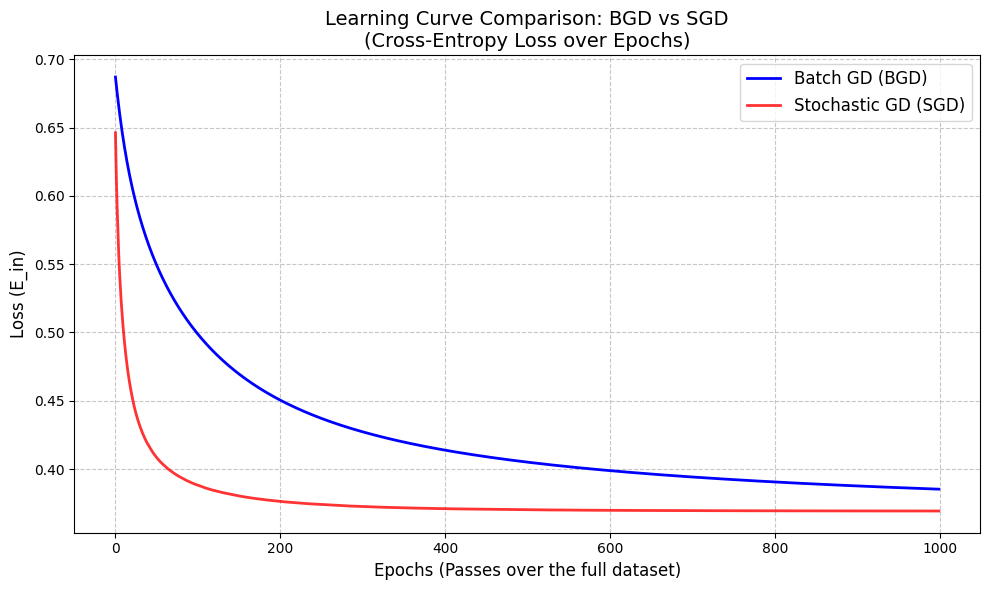

In [6]:
plt.figure(figsize=(10, 6))

# Plot BGD Loss (Smooth, steady decline)
plt.plot(losses_bgd, label='Batch GD (BGD)', color='blue', linewidth=2)

# Plot SGD Loss (Drops incredibly fast, but can be slightly noisy)
plt.plot(losses_sgd, label='Stochastic GD (SGD)', color='red', linewidth=2, alpha=0.8)

plt.title("Learning Curve Comparison: BGD vs SGD\n(Cross-Entropy Loss over Epochs)", fontsize=14)
plt.xlabel("Epochs (Passes over the full dataset)", fontsize=12)
plt.ylabel("Loss (E_in)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Zoom in on the first 100 epochs to see the dramatic difference in speed
# plt.xlim(0, 100) # Uncomment this line if you want to zoom in!

plt.tight_layout()
plt.show()